In [1]:
from pymcsimmod.parser import Parser
import pymcsimmod.model as model

from rich import print

import matplotlib.pyplot as plt
import numpy as np

import pytensor
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
from pytensor.link.jax.dispatch import jax_funcify

import jax
import jax.numpy as jnp
import diffrax

In [2]:
parser = Parser()
with open("../data/pred_prey.model") as file:
    parsed_model = parser.parse(file.read())

In [3]:
print(parsed_model)

Model(
    sections=[
        StatesSection(type='States', declarations=[Identifier(name='x'), Identifier(name='y')]),
        OutputsSection(type='Outputs', declarations=[]),
        InputsSection(type='Inputs', declarations=[]),
        Statement(lhs=Identifier(name='alpha'), rhs=Number(value=0.67)),
        Statement(lhs=Identifier(name='beta'), rhs=Number(value=1.33)),
        Statement(lhs=Identifier(name='gamma'), rhs=Number(value=1.0)),
        Statement(lhs=Identifier(name='delta'), rhs=Number(value=1.0)),
        InitializeSection(
            type='Initialize',
            statements=[
                Statement(lhs=Identifier(name='x'), rhs=Number(value=1.0)),
                Statement(lhs=Identifier(name='y'), rhs=Number(value=0.75))
            ]
        ),
        DynamicsSection(
            type='Dynamics',
            statements=[
                Statement(
                    lhs=DtVariable(identifier=Identifier(name='x')),
                    rhs=MathematicalExpression(
                        operator='-',
                        lhs=MathematicalExpression(
                            operator='*',
                            lhs=Identifier(name='alpha'),
                            rhs=Identifier(name='x')
                        ),
                        rhs=MathematicalExpression(
                            operator='*',
                            lhs=MathematicalExpression(
                                operator='*',
                                lhs=Identifier(name='beta'),
                                rhs=Identifier(name='x')
                            ),
                            rhs=Identifier(name='y')
                        )
                    )
                ),
                Statement(
                    lhs=DtVariable(identifier=Identifier(name='y')),
                    rhs=MathematicalExpression(
                        operator='-',
                        lhs=MathematicalExpression(
                            operator='*',
                            lhs=MathematicalExpression(
                                operator='*',
                                lhs=Identifier(name='gamma'),
                                rhs=Identifier(name='x')
                            ),
                            rhs=Identifier(name='y')
                        ),
                        rhs=MathematicalExpression(
                            operator='*',
                            lhs=Identifier(name='delta'),
                            rhs=Identifier(name='y')
                        )
                    )
                )
            ]
        )
    ]
)

# Run a diffrax model

Solve the pred/prey model using jax and diffrax and the parameters defined in pred_prey.model

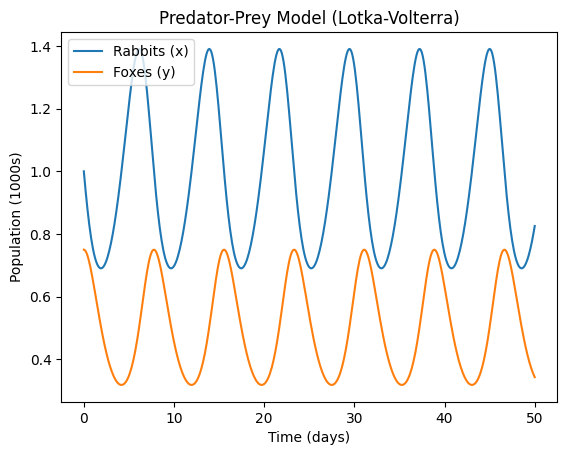

In [6]:
# Parameters for the predator/prey system
alpha = 0.67  # Birth rate of rabbits (1/d)
beta = 1.33   # Death rate of rabbits (1/d per 1000 foxes)
gamma = 1.00  # Birth rate of foxes (1/d per 1000 rabbits)
delta = 1.00  # Death rate of foxes (1/d)

# Initial conditions
x0 = 1.00  # Initial number of rabbits (1000s)
y0 = 0.75  # Initial number of foxes (1000s)

# Define the Lotka-Volterra system of ODEs
def lotka_volterra(t, y, args):
    alpha, beta, gamma, delta = args
    x, y = y
    dxdt = alpha * x - beta * x * y
    dydt = gamma * x * y - delta * y
    return jnp.array([dxdt, dydt])

# Time span for the simulation
t0 = 0.0  # Start time
t1 = 50.0  # End time

# Create the ODE term
ode_term = diffrax.ODETerm(lotka_volterra)

# Initial state
y0 = jnp.array([x0, y0])

# Solver configuration
solver = diffrax.Dopri5()
saveat = diffrax.SaveAt(ts=jnp.linspace(t0, t1, 500))

# Solve the ODE
solution = diffrax.diffeqsolve(
    ode_term,
    solver,
    t0=t0,
    t1=t1,
    dt0=0.1,
    y0=y0,
    args=(alpha, beta, gamma, delta),  # Pass parameters as args
    saveat=saveat,
)

# Plot the results
plt.plot(solution.ts, solution.ys[:, 0], label="Rabbits (x)")
plt.plot(solution.ts, solution.ys[:, 1], label="Foxes (y)")
plt.xlabel("Time (days)")
plt.ylabel("Population (1000s)")
plt.legend()
plt.title("Predator-Prey Model (Lotka-Volterra)")
plt.show()

# Use the parser

Parse out the MCSim model to run an ODE using diffrax/jax

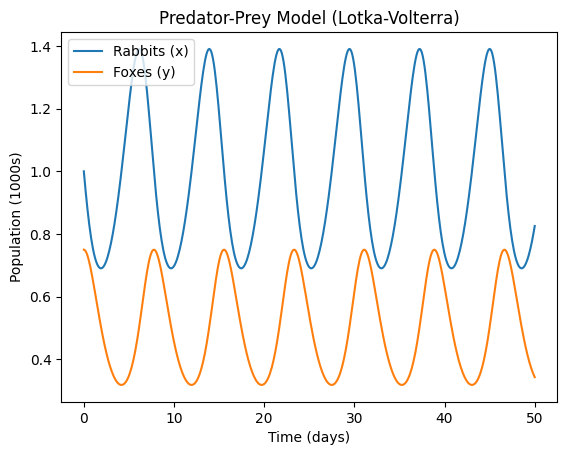

In [12]:
# Extract parameters from parsed_model
parameters = {}
for section in parsed_model.sections:
    if isinstance(section, model.Statement) and isinstance(section.rhs, model.Number):
        parameters[section.lhs.name] = section.rhs.value

# Extract initial conditions
initial_conditions = {}
for section in parsed_model.sections:
    if isinstance(section, model.InitializeSection):
        for statement in section.statements:
            initial_conditions[statement.lhs.name] = statement.rhs.value

# Extract dynamics
dynamics = {}
for section in parsed_model.sections:
    if isinstance(section, model.DynamicsSection):
        for statement in section.statements:
            variable = statement.lhs.identifier.name  # e.g., 'x' or 'y'
            dynamics[variable] = statement.rhs  # Store the MathematicalExpression

# Helper function to evaluate MathematicalExpression
def evaluate_expression(expr, variables):
    if isinstance(expr, model.Identifier):
        return variables[expr.name]
    elif isinstance(expr, model.Number):
        return expr.value
    elif isinstance(expr, model.MathematicalExpression):
        lhs = evaluate_expression(expr.lhs, variables)
        rhs = evaluate_expression(expr.rhs, variables)
        if expr.operator == '+':
            return lhs + rhs
        elif expr.operator == '-':
            return lhs - rhs
        elif expr.operator == '*':
            return lhs * rhs
        elif expr.operator == '/':
            return lhs / rhs
    raise ValueError("Unsupported expression type")

# Define generic ODE function
def generic_ode(t, y, args):
    # Unpack the arguments
    init_conds = {state: y[i] for i, state in enumerate(dynamics.keys())}
    variables = {**args}
    variables.update(init_conds)

    # Combine dynamics into list
    dydt = [evaluate_expression(dynamics[state], variables) for state in dynamics.keys()]
    
    return jnp.array(dydt)

# Run the predator-prey model using the parsed model
# Unpack parameters and initial conditions
x0, y0 = initial_conditions['x'], initial_conditions['y']

# Time span for the simulation
t0 = 0.0  # Start time
t1 = 50.0  # End time

# Create the ODE term
ode_term = diffrax.ODETerm(generic_ode)

# Initial state
y_init = jnp.array([x0, y0])

# Solver configuration
solver = diffrax.Dopri5()
saveat = diffrax.SaveAt(ts=jnp.linspace(t0, t1, 500))

# Solve the ODE
solution = diffrax.diffeqsolve(
    ode_term,
    solver,
    t0=t0,
    t1=t1,
    dt0=0.1,
    y0=y_init,
    args=parameters,  # Pass parameters as args
    saveat=saveat,
)

# Plot the results
plt.plot(solution.ts, solution.ys[:, 0], label="Rabbits (x)")
plt.plot(solution.ts, solution.ys[:, 1], label="Foxes (y)")
plt.xlabel("Time (days)")
plt.ylabel("Population (1000s)")
plt.legend()
plt.title("Predator-Prey Model (Lotka-Volterra)")
plt.show()